In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('House Info Updated.csv')
df

,Property_ID,Listing_Date,Sale_Price,Bedrooms,Bathrooms,SqFt_Living,SqFt_Lot,Floors,Waterfront,Year_Built,Year_Renovated,City,Zip_Code,Price_per_SqFt
0,PROP_00001,2026-04-24,1948950.0,4,3.5,4260,12780,2.5,0,1956,2021,Tech Park District,30045,457.5
1,PROP_00002,2025-07-28,272580.0,4,2.5,1540,9240,1.0,0,1956,0,Greenwood Valley,40082,177.0
2,PROP_00003,2025-06-13,328556.0,4,1.5,1485,2970,2.0,0,2004,2019,Greenwood Valley,40082,221.2
3,PROP_00004,2025-10-19,175685.0,1,1.0,857,4285,1.5,0,1982,0,Coastal Suburbs,20011,205.0
4,PROP_00005,2025-10-04,754880.0,4,3.5,3370,10110,3.0,0,2007,0,Greenwood Valley,40081,224.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10007,PROP_10246,2025-07-01,435050.0,4,2.0,1925,7700,2.0,0,1961,0,Greenwood Valley,40081,226.0
10008,PROP_10247,2026-04-11,380090.0,3,2.0,1910,11460,1.5,0,1971,0,Greenwood Valley,40082,199.0
10009,PROP_10248,2025-11-14,236924.0,2,2.5,971,4855,1.5,0,1974,0,Coastal Suburbs,20012,244.0
10010,PROP_10249,2025-09-01,357204.0,2,1.0,1751,3502,1.0,0,1990,0,Metro City,10004,204.0


In [3]:
city_summary = df.groupby('City').agg(
    Total_Sales=('Sale_Price', 'count'),
    Avg_Sale_Price=('Sale_Price', 'mean'),
    Avg_Price_per_SqFt=('Price_per_SqFt', 'mean'),
    Total_Revenue=('Sale_Price', 'sum')
).reset_index().round(2)

city_summary

,City,Total_Sales,Avg_Sale_Price,Avg_Price_per_SqFt,Total_Revenue
0,Coastal Suburbs,2457,492410.22,221.81,1.209852e+09
1,Greenwood Valley,2575,522476.23,226.28,1.345376e+09
2,Metro City,2508,515674.85,224.88,1.293313e+09
3,Tech Park District,2472,507358.18,225.39,1.254189e+09


In [4]:
waterfront_premiumness = df.groupby(['City', 'Waterfront']).agg(
    Average_Sale_Price=('Sale_Price', 'mean')
).reset_index().round(2)

waterfront_premiumness

,City,Waterfront,Average_Sale_Price
0,Coastal Suburbs,0,468016.69
1,Coastal Suburbs,1,1226686.33
2,Greenwood Valley,0,480669.48
3,Greenwood Valley,1,1777686.07
4,Metro City,0,487879.67
5,Metro City,1,1289147.66
6,Tech Park District,0,490840.57
7,Tech Park District,1,1074148.16


In [5]:
zip_medians = df.groupby('Zip_Code')['Sale_Price'].median().reset_index()

zip_ranked = zip_medians.sort_values(by='Sale_Price', ascending=False)

print("=== TOP 5 EXPENSIVE ZIP CODES ===")
print(zip_ranked.head())

print("\n=== BOTTOM 5 CHEAPEST ZIP CODES ===")
print(zip_ranked.tail())

=== TOP 5 EXPENSIVE ZIP CODES ===
    Zip_Code  Sale_Price
1      10002    356750.0
2      10003    356118.0
10     40082    353532.0
8      30046    350112.0
4      20011    344475.0

=== BOTTOM 5 CHEAPEST ZIP CODES ===
   Zip_Code  Sale_Price
3     10004    343360.0
9     40081    341822.5
0     10001    340681.0
6     20013    338808.0
5     20012    334350.0


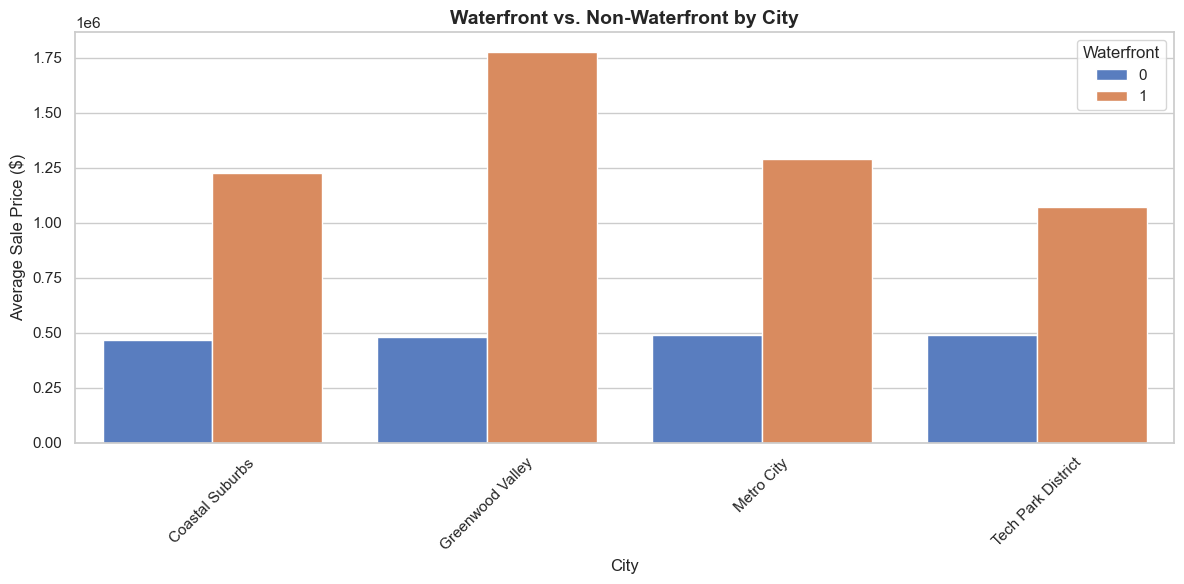

In [6]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=waterfront_premiumness, 
    x='City', 
    y='Average_Sale_Price', 
    hue='Waterfront', 
    palette='muted'
)

plt.title('Waterfront vs. Non-Waterfront by City', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2888\3564141647.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


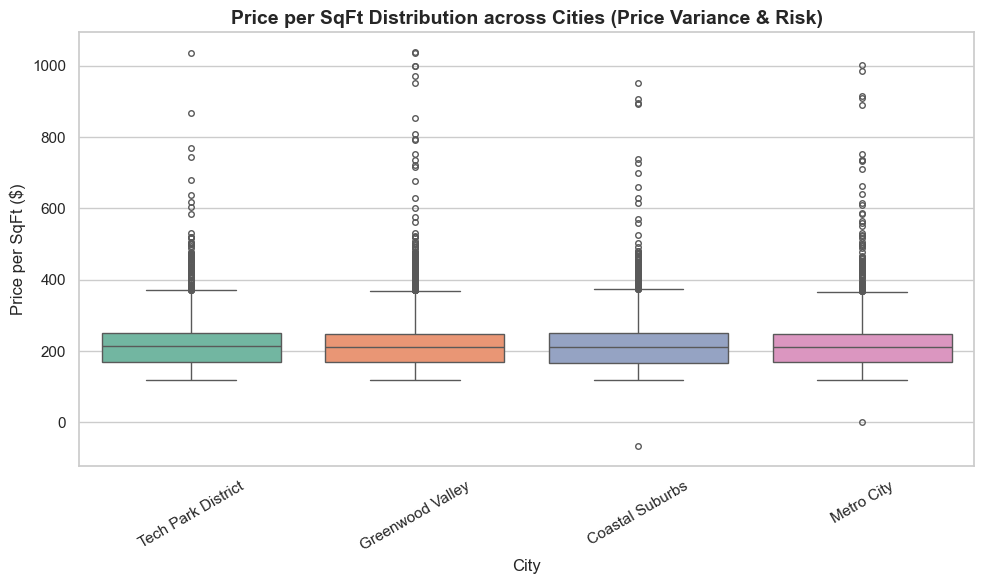

In [7]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df, 
    x='City', 
    y='Price_per_SqFt', 
    palette='Set2',
    fliersize=4
)

plt.title('Price per SqFt Distribution across Cities (Price Variance & Risk)', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Price per SqFt ($)', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [8]:
bins = [-np.inf, 1499, 3000, np.inf]
labels = ['Small', 'Medium', 'Large']

df['Property_Size_Tier'] = pd.cut(df['SqFt_Living'], bins=bins, labels=labels)

print(df[['SqFt_Living', 'Property_Size_Tier']].head(10))

   SqFt_Living Property_Size_Tier
0         4260              Large
1         1540             Medium
2         1485              Small
3          857              Small
4         3370              Large
5         2667             Medium
6         1403              Small
7         1495              Small
8         3856              Large
9         1437              Small


In [9]:
df['Property_Age'] = 2026 - df['Year_Built']

bins = [-np.inf, 10, 30, np.inf]
labels = ['New Construction', 'Mordern', 'Established']

df['Age_Group'] = pd.cut(df['Property_Age'], bins=bins, labels=labels)

print(df[['Year_Built', 'Age_Group']].head(10))

   Year_Built    Age_Group
0        1956  Established
1        1956  Established
2        2004      Mordern
3        1982  Established
4        2007      Mordern
5        1957  Established
6        1979  Established
7        1963  Established
8        1973  Established
9        2010      Mordern


In [10]:
df.to_csv('Housing.csv', index=False)